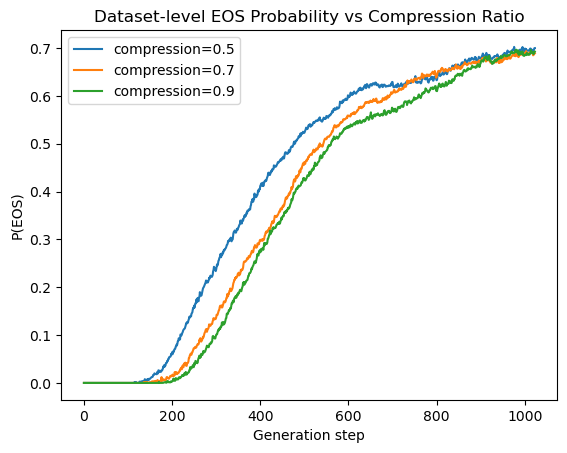

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

def mean_eos_curve(pred_path):
    results = [json.loads(line) for line in open(pred_path)]

    eos_profiles = [
        r['eos_prob_profile']
        for r in results
        if r.get('eos_prob_profile') is not None
    ]

    max_len = max(len(p) for p in eos_profiles)
    eos_matrix = np.full((len(eos_profiles), max_len), np.nan)

    for i, p in enumerate(eos_profiles):
        eos_matrix[i, :len(p)] = p

    return np.nanmean(eos_matrix, axis=0)


# --- compression ratios to compare ---
ratios = [0.5, 0.7,0.9]   # change as needed

plt.figure()

for ratio in ratios:
    path = f"{ratio}/predictions.jsonl"
    mean_eos = mean_eos_curve(path)
    plt.plot(mean_eos, label=f"compression={ratio}")

plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.title("Dataset-level EOS Probability vs Compression Ratio")
plt.legend()
plt.show()


In [5]:
def eos_spike_step(profile, tau=0.5):
    for i, p in enumerate(profile):
        if p > tau:
            return i
    return None


Compression ratio = 0.5
  Mean P(EOS) (overall): 0.4188
  Max  P(EOS):           0.7025
  Step of max P(EOS):    976

Compression ratio = 0.7
  Mean P(EOS) (overall): 0.3804
  Max  P(EOS):           0.6937
  Step of max P(EOS):    1003

Compression ratio = 0.9
  Mean P(EOS) (overall): 0.3610
  Max  P(EOS):           0.6966
  Step of max P(EOS):    981


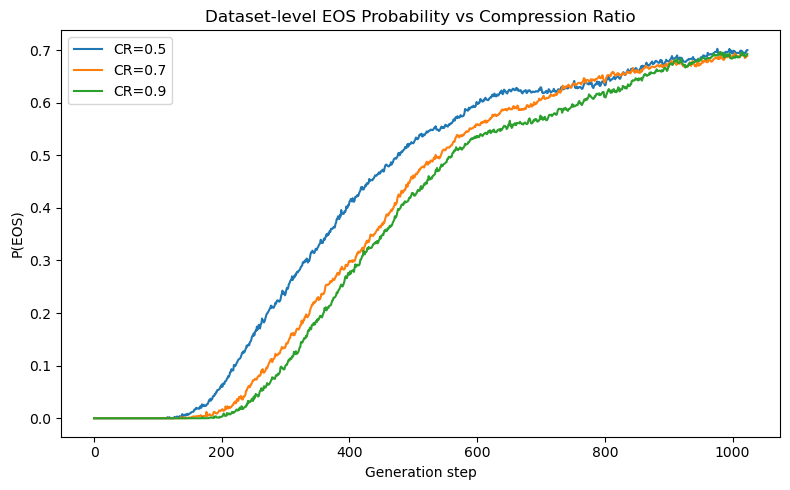

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt


def mean_eos_curve(pred_path):
    results = [json.loads(line) for line in open(pred_path)]

    eos_profiles = [
        r['eos_prob_profile']
        for r in results
        if r.get('eos_prob_profile') is not None
    ]

    if len(eos_profiles) == 0:
        return None

    max_len = max(len(p) for p in eos_profiles)
    eos_matrix = np.full((len(eos_profiles), max_len), np.nan)

    for i, p in enumerate(eos_profiles):
        eos_matrix[i, :len(p)] = p

    return np.nanmean(eos_matrix, axis=0)


# -------- compression ratios to compare --------
compression_ratios = [0.5, 0.7, 0.9]

plt.figure(figsize=(8, 5))

for ratio in compression_ratios:
    mean_eos = mean_eos_curve(f"{ratio}/predictions.jsonl")

    if mean_eos is not None:
        plt.plot(mean_eos, label=f"CR={ratio}")

        # 🔹 also PRINT summary statistics
        print(f"\nCompression ratio = {ratio}")
        print(f"  Mean P(EOS) (overall): {np.nanmean(mean_eos):.4f}")
        print(f"  Max  P(EOS):           {np.nanmax(mean_eos):.4f}")
        print(f"  Step of max P(EOS):    {np.nanargmax(mean_eos)}")


plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.title("Dataset-level EOS Probability vs Compression Ratio")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import json

results = [json.loads(line) for line in open("predictions.jsonl")]

spike_steps = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is not None:
        t = eos_spike_step(profile, tau=0.5)
        spike_steps.append(t)


FileNotFoundError: [Errno 2] No such file or directory: 'predictions.jsonl'

In [28]:
valid_spikes = [t for t in spike_steps if t is not None]

mean_spike = sum(valid_spikes) / len(valid_spikes)
median_spike = sorted(valid_spikes)[len(valid_spikes)//2]

print("Mean EOS spike step:", mean_spike)
print("Median EOS spike step:", median_spike)
print("Fraction with no EOS spike:",
      spike_steps.count(None) / len(spike_steps))


Mean EOS spike step: 307.3890577507599
Median EOS spike step: 305
Fraction with no EOS spike: 0.342



Compression ratio = 0.5
  Mean EOS spike step   : 418.442731277533
  Median EOS spike step : 367
  Fraction no EOS spike : 0.092
  Valid / Total samples : 454 / 500


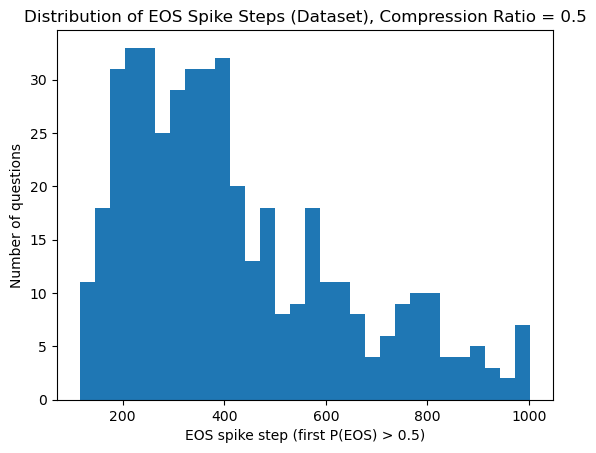


Compression ratio = 0.7
  Mean EOS spike step   : 475.14864864864865
  Median EOS spike step : 440
  Fraction no EOS spike : 0.112
  Valid / Total samples : 444 / 500


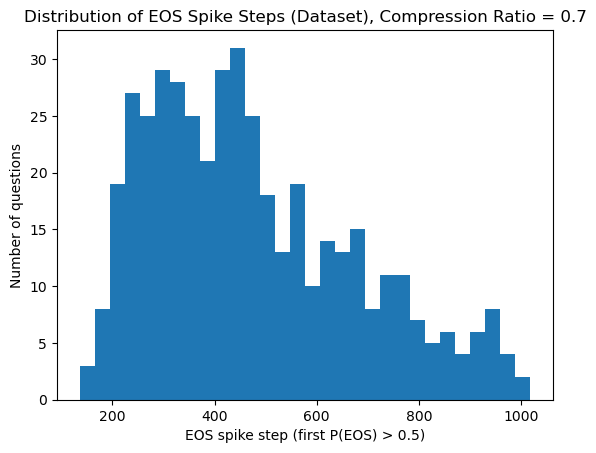


Compression ratio = 0.9
  Mean EOS spike step   : 505.6770601336303
  Median EOS spike step : 457
  Fraction no EOS spike : 0.102
  Valid / Total samples : 449 / 500


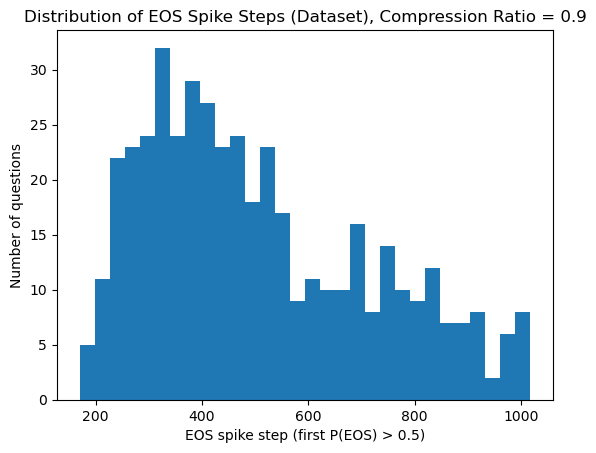

In [13]:
import json
import matplotlib.pyplot as plt

compression_ratios = [0.5, 0.7, 0.9]

for ratio in compression_ratios:
    results = [json.loads(line) for line in open(f"{ratio}/predictions.jsonl")]

    spike_steps = []

    for r in results:
        profile = r.get('eos_prob_profile')
        if profile is not None:
            t = eos_spike_step(profile, tau=0.5)
            spike_steps.append(t)
        else:
            spike_steps.append(None)

    valid_spikes = [t for t in spike_steps if t is not None]

    mean_spike = sum(valid_spikes) / len(valid_spikes) if valid_spikes else None
    median_spike = sorted(valid_spikes)[len(valid_spikes) // 2] if valid_spikes else None
    frac_no_spike = spike_steps.count(None) / len(spike_steps)

    print(f"\nCompression ratio = {ratio}")
    print(f"  Mean EOS spike step   : {mean_spike}")
    print(f"  Median EOS spike step : {median_spike}")
    print(f"  Fraction no EOS spike : {frac_no_spike:.3f}")
    print(f"  Valid / Total samples : {len(valid_spikes)} / {len(spike_steps)}")

    

    plt.figure()
    plt.hist(valid_spikes, bins=30)
    plt.xlabel("EOS spike step (first P(EOS) > 0.5)")
    plt.ylabel("Number of questions")
    plt.title(f"Distribution of EOS Spike Steps (Dataset), Compression Ratio = {ratio}")
    plt.show()


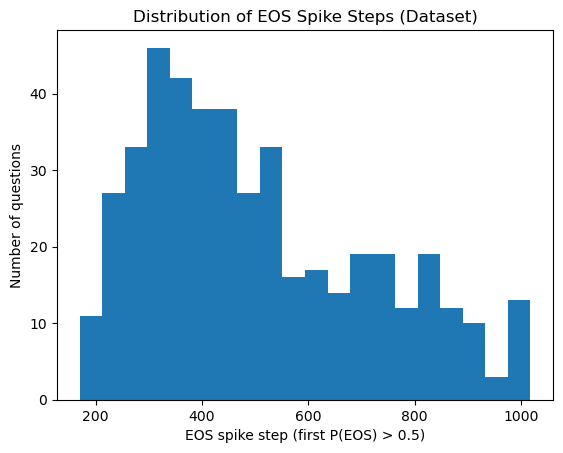

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(valid_spikes, bins=20)
plt.xlabel("EOS spike step (first P(EOS) > 0.5)")
plt.ylabel("Number of questions")
plt.title("Distribution of EOS Spike Steps (Dataset)")
plt.show()


In [30]:
correct_spikes = []
wrong_spikes = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is None:
        continue
    t = eos_spike_step(profile)
    if t is None:
        continue
    if r['accuracy']:
        correct_spikes.append(t)
    else:
        wrong_spikes.append(t)


In [33]:
def safe_mean(x):
    return sum(x) / len(x) if len(x) > 0 else None

avg_correct = safe_mean(correct_spikes)
avg_incorrect = safe_mean(wrong_spikes)

print(f"Average EOS spike step (correct):   {avg_correct}")
print(f"Average EOS spike step (incorrect): {avg_incorrect}")

print(f"#correct samples used:   {len(correct_spikes)}")
print(f"#incorrect samples used: {len(wrong_spikes)}")


Average EOS spike step (correct):   288.6057692307692
Average EOS spike step (incorrect): 339.6776859504132
#correct samples used:   208
#incorrect samples used: 121


In [34]:
import scipy
from scipy.stats import ttest_ind

t, p = ttest_ind(correct_spikes, wrong_spikes, equal_var=False)
print("p-value:", p)


p-value: 4.7239622902727414e-06


In [15]:
def safe_mean(x):
    return sum(x) / len(x) if len(x) > 0 else None


===== Compression Ratio = 0.5 =====
Average EOS spike step (correct):   360.1490196078431
Average EOS spike step (incorrect): 493.14070351758795
#correct samples used:   255
#incorrect samples used: 199


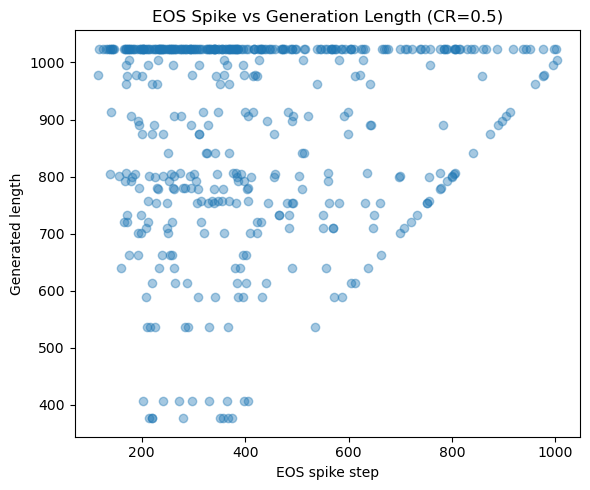


===== Compression Ratio = 0.7 =====
Average EOS spike step (correct):   428.71380471380473
Average EOS spike step (incorrect): 568.9659863945578
#correct samples used:   297
#incorrect samples used: 147


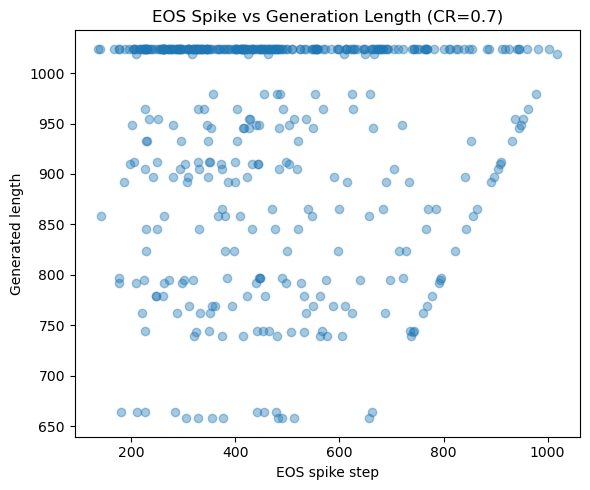


===== Compression Ratio = 0.9 =====
Average EOS spike step (correct):   460.41100323624596
Average EOS spike step (incorrect): 605.5857142857143
#correct samples used:   309
#incorrect samples used: 140


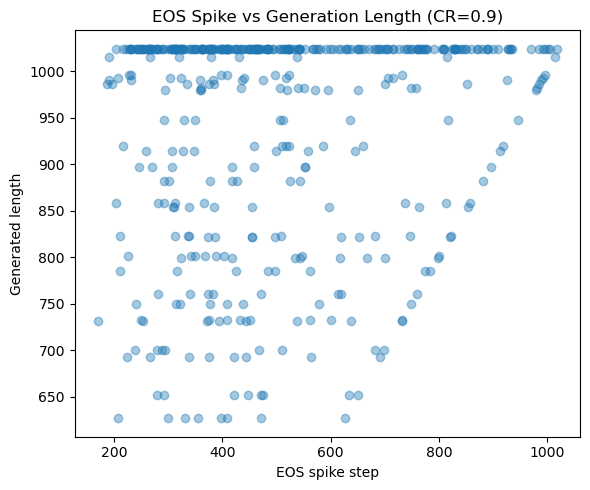

In [16]:
import json
import matplotlib.pyplot as plt

compression_ratios = [0.5, 0.7, 0.9]

for ratio in compression_ratios:
    print(f"\n===== Compression Ratio = {ratio} =====")

    results = [
        json.loads(line)
        for line in open(f"{ratio}/predictions.jsonl")
    ]

    correct_spikes = []
    wrong_spikes = []

    x = []  # EOS spike step
    y = []  # generated length

    for r in results:
        profile = r.get('eos_prob_profile')
        if profile is None:
            continue

        t = eos_spike_step(profile, tau=0.5)
        if t is None:
            continue

        # correct vs incorrect
        if r.get('accuracy'):
            correct_spikes.append(t)
        else:
            wrong_spikes.append(t)

        # scatter data
        x.append(t)
        y.append(r.get('generated_length'))

    # ---- print statistics ----
    avg_correct = safe_mean(correct_spikes)
    avg_wrong = safe_mean(wrong_spikes)

    print(f"Average EOS spike step (correct):   {avg_correct}")
    print(f"Average EOS spike step (incorrect): {avg_wrong}")
    print(f"#correct samples used:   {len(correct_spikes)}")
    print(f"#incorrect samples used: {len(wrong_spikes)}")

    # ---- scatter plot ----
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.4)
    plt.xlabel("EOS spike step")
    plt.ylabel("Generated length")
    plt.title(f"EOS Spike vs Generation Length (CR={ratio})")
    plt.tight_layout()
    plt.show()


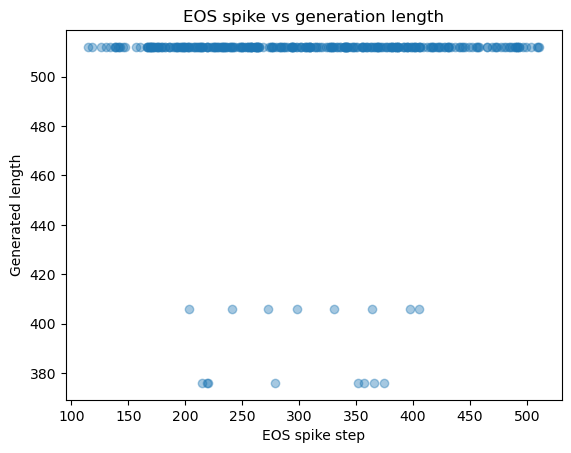

In [35]:
import matplotlib.pyplot as plt

x = []
y = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is None:
        continue
    t = eos_spike_step(profile)
    if t is None:
        continue
    x.append(t)
    y.append(r['generated_length'])

plt.scatter(x, y, alpha=0.4)
plt.xlabel("EOS spike step")
plt.ylabel("Generated length")
plt.title("EOS spike vs generation length")
plt.show()


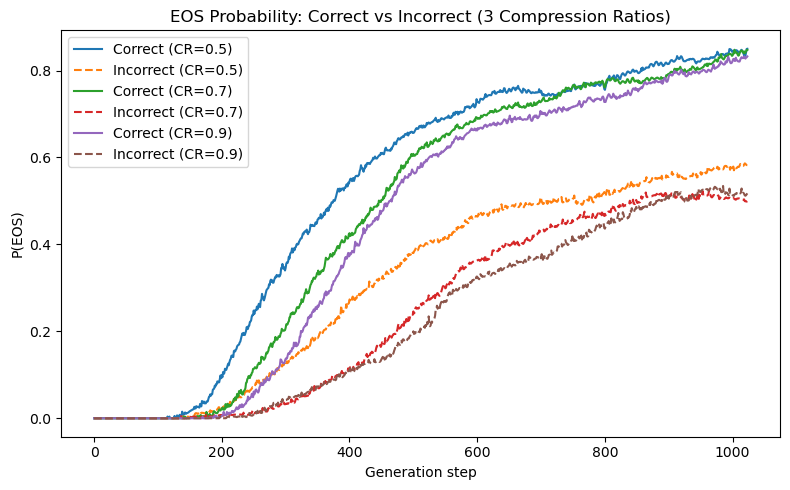

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt


# ---------- helper function ----------
def mean_eos_curve(results_subset):
    profiles = [
        r['eos_prob_profile']
        for r in results_subset
        if r.get('eos_prob_profile') is not None
    ]

    if len(profiles) == 0:
        return None

    max_len = max(len(p) for p in profiles)
    mat = np.full((len(profiles), max_len), np.nan)

    for i, p in enumerate(profiles):
        mat[i, :len(p)] = p

    return np.nanmean(mat, axis=0)


# ---------- compression ratios ----------
compression_ratios = [0.5, 0.7, 0.9]

plt.figure(figsize=(8, 5))

for ratio in compression_ratios:
    # load results
    results = [
        json.loads(line)
        for line in open(f"{ratio}/predictions.jsonl")
    ]

    # split by correctness
    correct = [r for r in results if r.get('accuracy') is True]
    incorrect = [r for r in results if r.get('accuracy') is False]

    # compute curves
    correct_curve = mean_eos_curve(correct)
    incorrect_curve = mean_eos_curve(incorrect)

    # plot
    if correct_curve is not None:
        plt.plot(
            correct_curve,
            label=f"Correct (CR={ratio})"
        )

    if incorrect_curve is not None:
        plt.plot(
            incorrect_curve,
            linestyle="--",
            label=f"Incorrect (CR={ratio})"
        )


# ---------- plot formatting ----------
plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.title("EOS Probability: Correct vs Incorrect (3 Compression Ratios)")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
def mean_eos(results_subset):
    profiles = [r['eos_prob_profile'] for r in results_subset if r.get('eos_prob_profile')]
    max_len = max(len(p) for p in profiles)
    mat = np.full((len(profiles), max_len), np.nan)
    for i, p in enumerate(profiles):
        mat[i, :len(p)] = p
    return np.nanmean(mat, axis=0)

correct = [r for r in results if r['accuracy']]
incorrect = [r for r in results if not r['accuracy']]

plt.plot(mean_eos(correct), label="Correct")
plt.plot(mean_eos(incorrect), label="Incorrect")
plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.legend()
plt.title("EOS probability: Correct vs Incorrect, CR : 0.5")
plt.show()


NameError: name 'results' is not defined

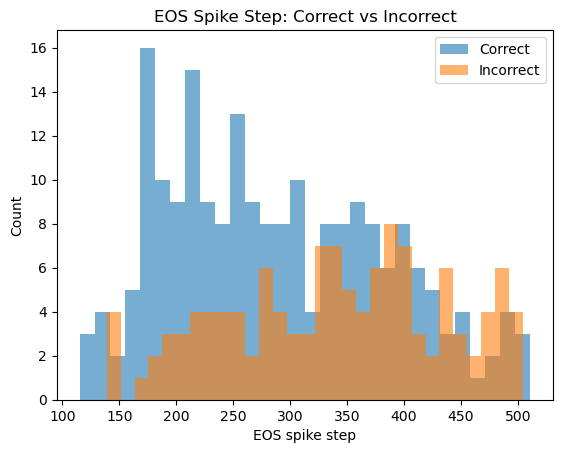

In [31]:
plt.figure()
plt.hist(correct_spikes, bins=30, alpha=0.6, label="Correct")
plt.hist(wrong_spikes, bins=30, alpha=0.6, label="Incorrect")
plt.xlabel("EOS spike step")
plt.ylabel("Count")
plt.title("EOS Spike Step: Correct vs Incorrect")
plt.legend()
plt.show()
